# Hotel Cancellation — Decision Tree Model

Loads the `X`/`Y` train/test splits from `feature_prep.ipynb`, carves a stratified validation set out of train, sets a majority-class baseline, then trains and tunes a decision tree to predict `is_canceled`. The suspected-leaky `deposit_type_Non Refund` column is held out of the headline model and added back at the end to measure its effect. Per the milestone plan, models are judged on ROC-AUC and PR-AUC.

## 1. Setup

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

PROCESSED_DIR = "../data/processed"

## 2. Load Processed Data

Trees split one feature at a time, so scaling doesn't matter to them. We reuse the scaled `X` files from `feature_prep.ipynb` anyway; that way every model trains on identical inputs.

In [42]:
X_train_full = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
Y_train_full = pd.read_csv(f"{PROCESSED_DIR}/Y_train.csv")["is_canceled"]
Y_test = pd.read_csv(f"{PROCESSED_DIR}/Y_test.csv")["is_canceled"]

print("X_train_full shape:", X_train_full.shape, "  Y_train_full shape:", Y_train_full.shape)
print("X_test shape:", X_test.shape, "  Y_test shape:", Y_test.shape)

X_train_full shape: (95368, 42)   Y_train_full shape: (95368,)
X_test shape: (23840, 42)   Y_test shape: (23840,)


## 3. Train / Validation Split

Carve a stratified validation set out of train for tuning. Test stays untouched until the final evaluation.

In [43]:
X_train_mini, X_val, Y_train_mini, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.2, random_state=1234, stratify=Y_train_full)

print("X_train_mini shape:", X_train_mini.shape)
print("X_val shape:", X_val.shape)
print("Cancel rate train:", round(Y_train_mini.mean(), 4))
print("Cancel rate val:", round(Y_val.mean(), 4))
print("Cancel rate test:", round(Y_test.mean(), 4))

X_train_mini shape: (76294, 42)
X_val shape: (19074, 42)
Cancel rate train: 0.3708
Cancel rate val: 0.3708
Cancel rate test: 0.3708


All three splits land at the same 37.1% cancel rate, so the stratification worked.

## 4. Majority Baseline

The "stupid" baseline: predict stayed for everything.

In [44]:
# Predicting 0 (stayed) for every booking
majority_accuracy_val = np.sum(Y_val == 0) / len(Y_val)
majority_accuracy_test = np.sum(Y_test == 0) / len(Y_test)

print("Majority baseline accuracy (val):", round(majority_accuracy_val, 4))
print("Majority baseline accuracy (test):", round(majority_accuracy_test, 4))

Majority baseline accuracy (val): 0.6292
Majority baseline accuracy (test): 0.6292


The baseline scores 62.9% accuracy without catching a single cancellation, so accuracy is the wrong metric here. The real floor to beat is PR-AUC 0.371 (the cancel rate) and ROC-AUC 0.5.

## 5. Baseline Random Forest Tree

Similar to the Decison tree algorithm, we hold `deposit_type_Non Refund` out of the headline model; its 99.4% cancel rate in the EDA looks like leakage, a feature that encodes the outcome rather than predicting it.

In [45]:
# Hold out the suspected-leaky deposit column (added back in section 8)
leaky_col = "deposit_type_Non Refund"
X_train_tree = X_train_mini.drop(columns=[leaky_col])
X_val_tree = X_val.drop(columns=[leaky_col])
X_test_tree = X_test.drop(columns=[leaky_col])

print("X_train_tree shape:", X_train_tree.shape)

X_train_tree shape: (76294, 41)


In [46]:
def pr_roc_scores(model, X, Y):
    # Score a fitted model on one split using the predicted cancellation probability
    probs = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(Y, probs)
    pr = average_precision_score(Y, probs)
    return roc, pr

In [48]:
baseline_rf = RandomForestClassifier(n_estimators=2, n_jobs =1, random_state=7, max_depth =8)
baseline_rf.fit(X_train_tree, Y_train_mini)

train_roc, train_pr = pr_roc_scores(baseline_rf, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(baseline_rf, X_val_tree, Y_val)

print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))

Train ROC-AUC: 0.8747   Train PR-AUC: 0.8217
Val ROC-AUC: 0.8722   Val PR-AUC: 0.8178


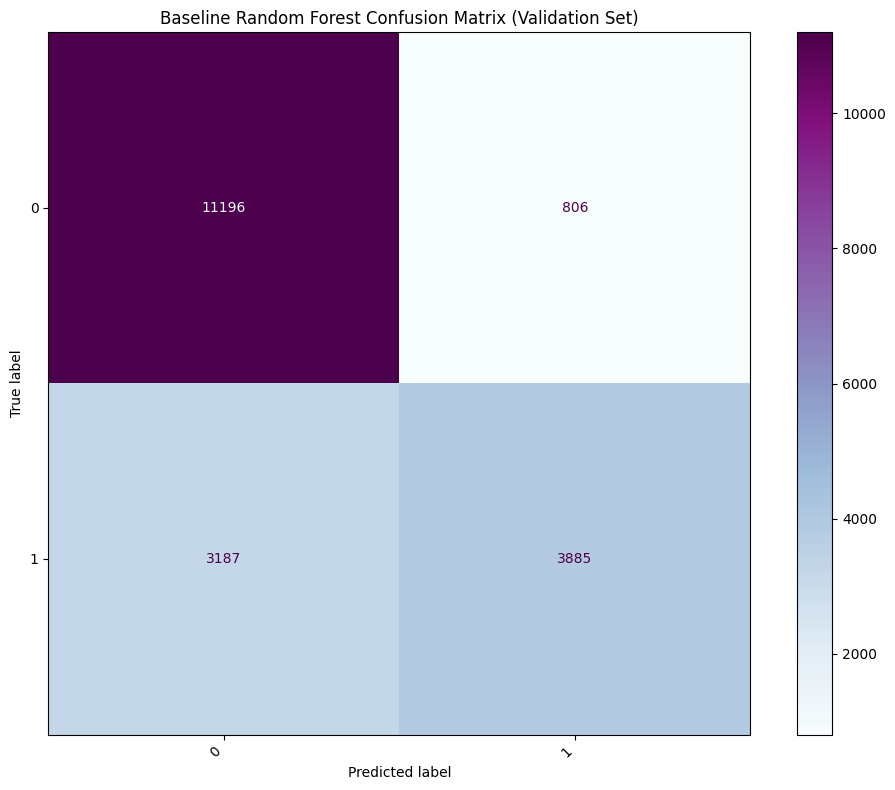

In [49]:
y_val_pred = baseline_rf.predict(X_val_tree)

cm = confusion_matrix(Y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap = 'BuPu')
plt.title("Baseline Random Forest Confusion Matrix (Validation Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ADD SENTENCE

## 6. Hyperparameter Tuning

sentence bout hypertuned parameters

In [52]:
tuned_rf = RandomForestClassifier(n_estimators=100, n_jobs = -1, random_state=7, max_depth =None)
tuned_rf.fit(X_train_tree, Y_train_mini)

# y_train_pred = baseline_rf2.predict(X_train_tree)
y_val_pred = tuned_rf.predict(X_val_tree)

train_roc, train_pr = pr_roc_scores(tuned_rf, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(tuned_rf, X_val_tree, Y_val)

print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))

Train ROC-AUC: 0.9996   Train PR-AUC: 0.9993
Val ROC-AUC: 0.9504   Val PR-AUC: 0.9307


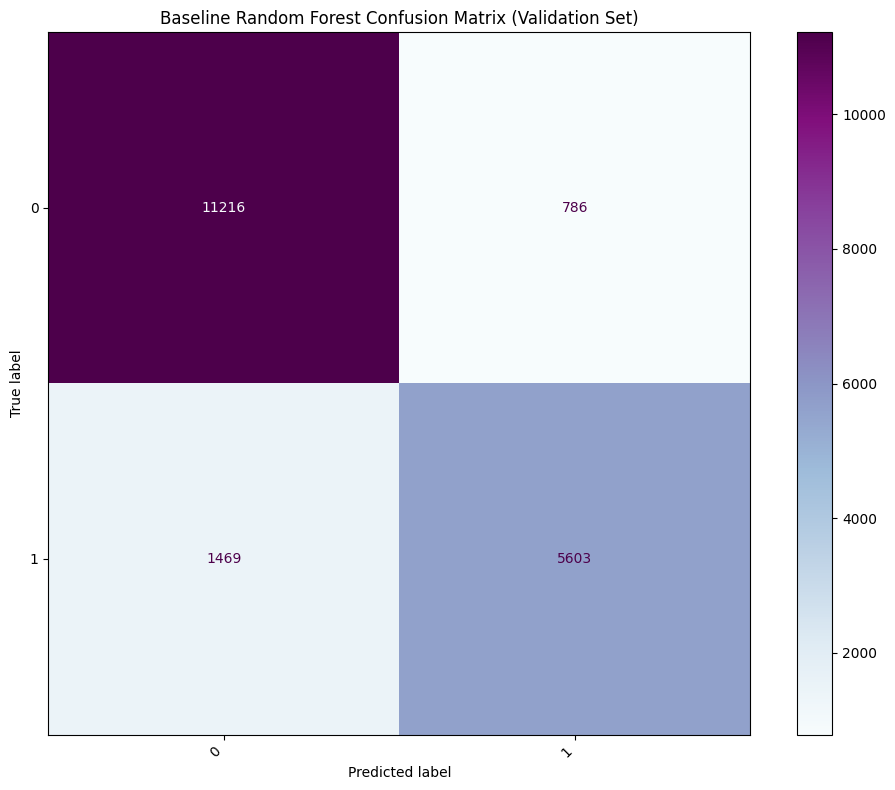

In [54]:
y_val_pred = tuned_rf.predict(X_val_tree)

cm = confusion_matrix(Y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap = 'BuPu')
plt.title("Baseline Random Forest Confusion Matrix (Validation Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
#CHART FOR AUC ROC

## 7. Final Model Evaluation



In [ ]:
test_roc, test_pr = pr_roc_scores(tuned_rf, X_test_tree, Y_test)

print("Test ROC-AUC:", round(test_roc, 4))
print("Test PR-AUC:", round(test_pr, 4))

Test ROC-AUC: 0.9491
Test PR-AUC: 0.929
Test accuracy: 0.8818
Test precision: 0.876
Test recall: 0.7936
Test F1: 0.8328


In [58]:
test_preds = tuned_rf.predict(X_test_tree)

print("Test accuracy:", round(accuracy_score(Y_test, test_preds), 4))
print("Test precision:", round(precision_score(Y_test, test_preds), 4))
print("Test recall:", round(recall_score(Y_test, test_preds), 4))
print("Test F1:", round(f1_score(Y_test, test_preds), 4))

Test accuracy: 0.8818
Test precision: 0.876
Test recall: 0.7936
Test F1: 0.8328


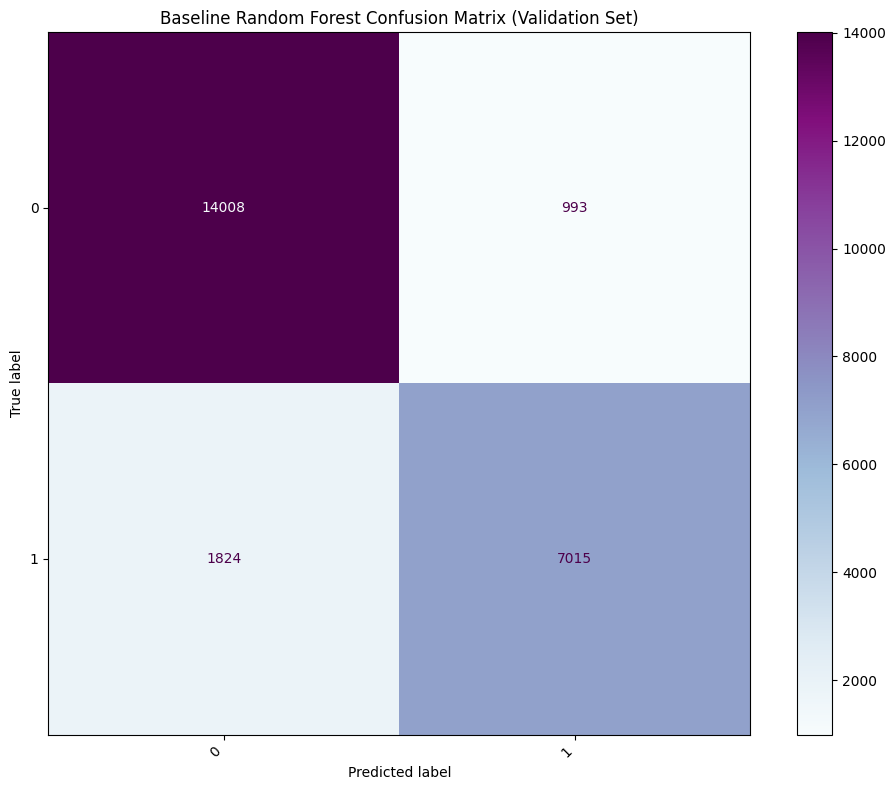

In [59]:
cm = confusion_matrix(Y_test, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap = 'BuPu')
plt.title("Baseline Random Forest Confusion Matrix (Validation Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Leakage Check



In [ ]:
leaky_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=None)
leaky_rf.fit(X_train_mini, Y_train_mini)

leaky_val_roc, leaky_val_pr = pr_roc_scores(leaky_rf, X_val, Y_val)
leaky_test_roc, leaky_test_pr = pr_roc_scores(leaky_rf, X_test, Y_test)

print("Without deposit col  val PR-AUC:", round(val_pr, 4), "  test PR-AUC:", round(test_pr, 4))
print("With deposit col     val PR-AUC:", round(leaky_val_pr, 4), "  test PR-AUC:", round(leaky_test_pr, 4))

Without deposit col  val PR-AUC: 0.9307   test PR-AUC: 0.929
With deposit col     val PR-AUC: 0.9305   test PR-AUC: 0.9293


sentence

## 9. Feature Importance

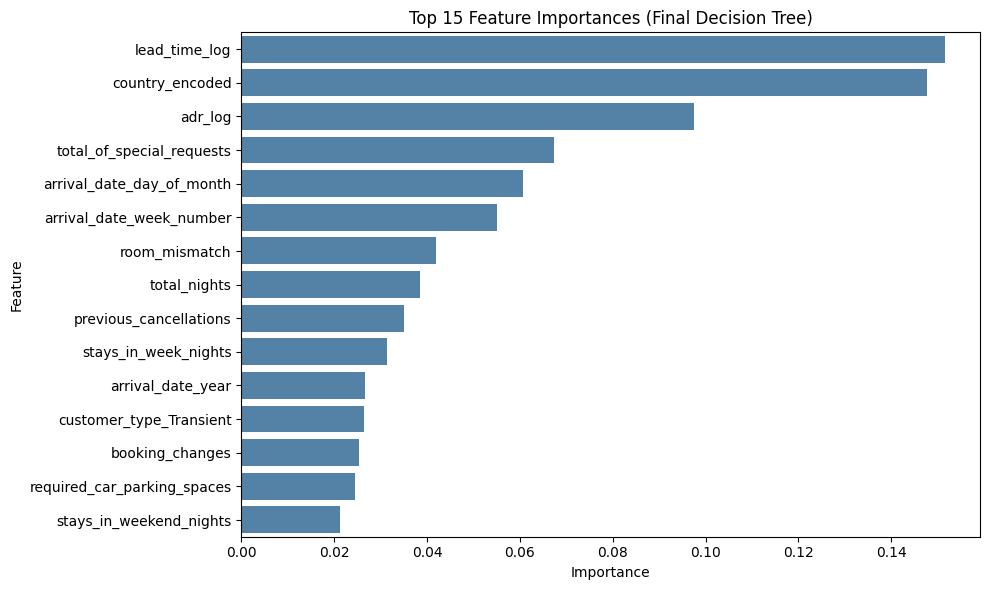

In [ ]:
importances = pd.Series(tuned_rf.feature_importances_, index=X_train_tree.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, color="steelblue")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

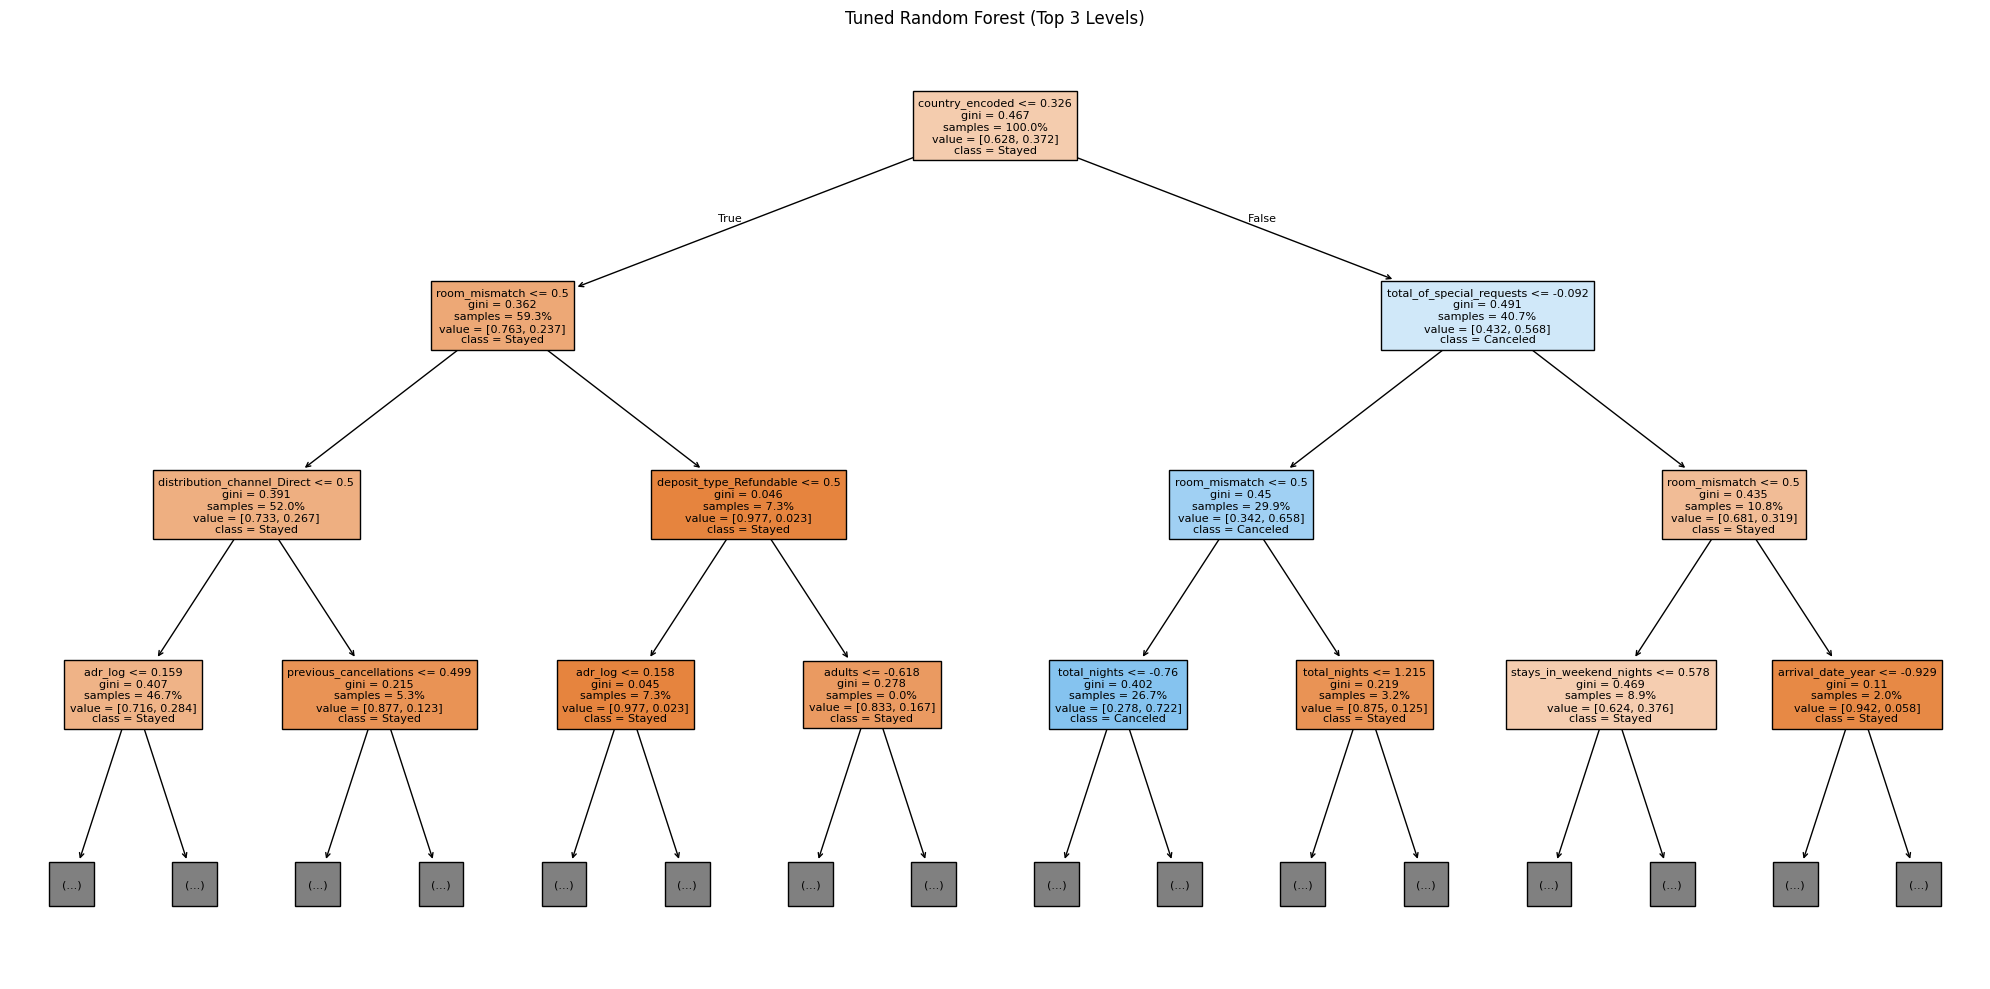

In [71]:
plt.figure(figsize=(20, 10))
plot_tree(tuned_rf.estimators_[0], max_depth=3, feature_names=X_train_tree.columns, class_names=["Stayed", "Canceled"], filled=True, proportion=True, fontsize=8)
plt.title("Tuned Random Forest (Top 3 Levels)")
plt.tight_layout()
plt.show()

Sentence about whats changed

## 10. Summary

| Model | Val ROC-AUC | Val PR-AUC | Test ROC-AUC | Test PR-AUC |
|---|---|---|---|---|
| Majority baseline | x | 0.x | 0.x | 0.x |
| Decision tree (depth 12, min_samples_leaf 25) | 0.x | 0.x | 0.x | 0.x |

write something